In [ ]:
import os
!pip install pydicom -qq
import pydicom

def get_dicom_duration(dicom_path):
    try:
        ds = pydicom.dcmread(dicom_path, force=True)

        # Common tags for temporal information
        # (0018,1065) Frame Time - Time in ms between frames
        # (0018,1066) Frame Time Vector - List of times in ms
        # (0028,0008) Number of Frames

        duration_seconds = None

        # Attempt to get duration from Frame Time and Number of Frames
        if 'FrameTime' in ds and 'NumberOfFrames' in ds:
            frame_time_ms = ds.FrameTime
            num_frames = ds.NumberOfFrames
            duration_seconds = (frame_time_ms * num_frames) / 1000.0
            print(f"  Detected FrameTime: {frame_time_ms} ms, NumberOfFrames: {num_frames}")
            print(f"  Calculated duration: {duration_seconds:.2f} seconds")

        elif 'WaveformSequence' in ds:
            # This is a more complex scenario, often requires parsing within the sequence
            # For simplicity, we'll just indicate its presence for now.
            # A full implementation would iterate through items in the sequence to find timing.
            print("  'WaveformSequence' found, but detailed duration extraction is complex and not implemented here.")
            # You might look for (0018,1063) "Time Slice Vector" or other related tags.

        else:
            print("  No common timing tags (FrameTime, NumberOfFrames) found for direct duration calculation.")

        return duration_seconds

    except pydicom.errors.InvalidDicomError:
        print(f"  Error: {dicom_path} is not a valid DICOM file.")
        return None
    except Exception as e:
        print(f"  An error occurred while processing {dicom_path}: {e}")
        return None

# Example usage with one of your DICOM files (uncomment to run and test):
# dicom_test_path = '/content/drive/MyDrive/DICOM/202603121715130176VAS.DCM'
# print(f"\nAttempting to extract duration from: {os.path.basename(dicom_test_path)}")
# extracted_duration = get_dicom_duration(dicom_test_path)
# if extracted_duration is not None:
#     print(f"Extracted duration for test DICOM: {extracted_duration:.2f} seconds")
# else:
#     print("Could not extract duration for test DICOM.")


### Reflux Detection from Waveform Images (Clean Start)

We will now implement the reflux detection pipeline using the provided image. The goal is to detect and measure reflux from the Doppler waveform.

#### Step 1: Load waveform Image

This step loads the image and displays it. We will use the provided screenshot as the input for this pipeline.

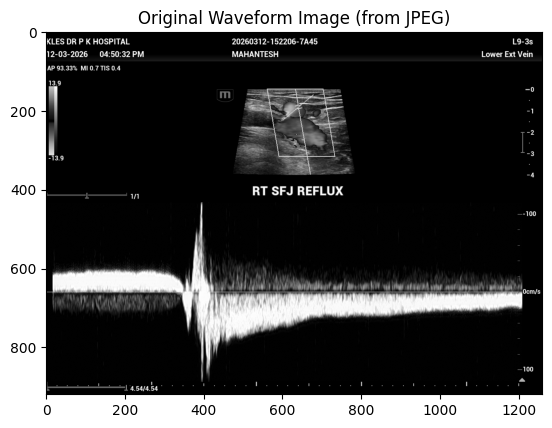

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Using a JPEG image path from the USG JPEG_MP4 directory
path = '/content/drive/MyDrive/USG JPEG_MP4/202603121715130176VAS.JPG'

# Load the image using OpenCV as grayscale
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Image not found at {path}")

# Ensure the image is 8-bit unsigned integer (common for grayscale images)
# cv2.imread(..., cv2.IMREAD_GRAYSCALE) usually handles this, but a check is good
if img.dtype != np.uint8:
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.imshow(img, cmap='gray')
plt.title("Original Waveform Image (from JPEG)")
plt.show()

In [ ]:
import os

dicom_dir = '/content/drive/MyDrive/DICOM/'
if os.path.exists(dicom_dir):
    dicom_files = [f for f in os.listdir(dicom_dir) if f.endswith('.DCM')]
    print("Available DICOM files:")
    for f in dicom_files:
        print(f)
else:
    print(f"DICOM directory not found: {dicom_dir}")

Available DICOM files:
202603121707100175VAS.DCM
202603121523080141VAS.DCM
202603121715130176VAS.DCM
202603121651180145VAS.DCM
202603121716130178VAS.DCM
202603121717100179VAS.DCM
202603121718040180VAS.DCM
202603121652080148VAS.DCM
202603121653180149VAS.DCM
202603121654020150VAS.DCM
202603121722530183VAS.DCM
202603121724470185VAS.DCM
202603121725210186VAS.DCM
202603121723480184VAS.DCM
202603121725590187VAS.DCM
202603121726460188VAS.DCM
202603121655120156VAS.DCM
202603121727210189VAS.DCM
202603121727470190VAS.DCM
202603121728210191VAS.DCM
202603121728540192VAS.DCM
202603121729160193VAS.DCM
202603121729440194VAS.DCM
202603121658530164VAS.DCM
202603121730410195VAS.DCM
202603121658590166VAS.DCM
202603121731520196VAS.DCM
202603121732490198VAS.DCM
202603121732220197VAS.DCM
202603121700070170VAS.DCM
202603121700240171VAS.DCM
202603121722020182VAS.DCM
202603121735260200VAS.DCM
202603121720190181VAS.DCM
202603121734350199VAS.DCM


In [ ]:
import os

usg_dir = '/content/drive/MyDrive/USG JPEG_MP4'

if os.path.exists(usg_dir):
    usg_files = os.listdir(usg_dir)
    print(f"Available files in {usg_dir}:")
    for f in usg_files:
        print(f)
else:
    print(f"Directory not found: {usg_dir}")

Available files in /content/drive/MyDrive/USG JPEG_MP4:
202603121523080141VAS.JPG
202603121715130176VAS.JPG
202603121707100175VAS.JPG
202603121716130178VAS.mp4
202603121717100179VAS.JPG
202603121651180145VAS.JPG
202603121718040180VAS.JPG
202603121652080148VAS.mp4
202603121654020150VAS.JPG
202603121653180149VAS.mp4
202603121722530183VAS.mp4
202603121724470185VAS.mp4
202603121725210186VAS.mp4
202603121723480184VAS.mp4
202603121655120156VAS.JPG
202603121727210189VAS.JPG
202603121727470190VAS.JPG
202603121726460188VAS.JPG
202603121725590187VAS.mp4
202603121728210191VAS.mp4
202603121728540192VAS.mp4
202603121729160193VAS.mp4
202603121729440194VAS.mp4
202603121658530164VAS.mp4
202603121730410195VAS.mp4
202603121700070170VAS.JPG
202603121700240171VAS.JPG
202603121722020182VAS.JPG
202603121732220197VAS.JPG
202603121658590166VAS.mp4
202603121735260200VAS.JPG
202603121732490198VAS.JPG
202603121731520196VAS.JPG
202603121720190181VAS.JPG
202603121734350199VAS.JPG


#### Step 2: Crop waveform (bottom half)

This step crops the image to focus on the bottom half, where the waveform of interest is typically located.

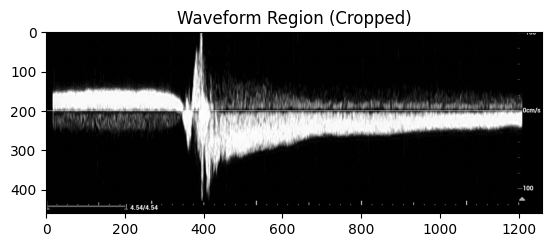

In [ ]:
h, w = img.shape

wave = img[int(h*0.5):h, :]

plt.imshow(wave, cmap='gray')
plt.title("Waveform Region (Cropped)")
plt.show()

#### Step 3: Convert to binary signal

This step normalizes the cropped waveform and applies Otsu's thresholding to convert it into a binary signal, making the waveform contours clearer.

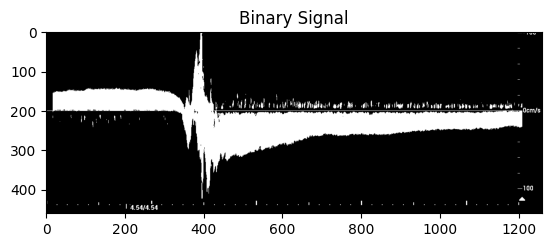

In [ ]:
# normalize
wave = cv2.normalize(wave, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# threshold
_, binary = cv2.threshold(wave, 0, 255, cv2.THRESH_OTSU)

plt.imshow(binary, cmap='gray')
plt.title("Binary Signal")
plt.show()

#### Step 4: Detect baseline

Here, we determine a simple baseline position for the waveform, which will be used to identify signals below it.

In [ ]:
baseline = binary.shape[0] // 2
print(f"Detected baseline at row: {baseline}")

Detected baseline at row: 230


#### Step 5: Extract reflux signal

This step iterates through the binary waveform to detect columns where a signal is present below the established baseline.

In [ ]:
signal = []

for x in range(binary.shape[1]):
    col = binary[:, x]

    # Check for non-zero pixels (waveform signal) below the baseline
    below = np.where(col[baseline:] > 0)[0]

    if len(below) > 0:
        signal.append(1) # Signal detected below baseline
    else:
        signal.append(0) # No signal detected below baseline

print(f"Extracted signal length: {len(signal)}")

Extracted signal length: 1260


#### Step 6: Compute reflux duration

Finally, we compute the maximum consecutive length of the detected reflux signal in pixels.

In [ ]:
max_len = 0
curr = 0

for s in signal:
    if s == 1:
        curr += 1
        max_len = max(max_len, curr)
    else:
        curr = 0

print("Reflux length (pixels):", max_len)

Reflux length (pixels): 836


#### Step 7: Convert pixel duration to seconds

Based on the observed total width of the waveform (~1200 px) corresponding to a total time of ~6.6 seconds, we can calculate the time per pixel and then the reflux duration in seconds.

In [ ]:
total_width_pixels = 1200
total_time_seconds = 6.6

time_per_pixel = total_time_seconds / total_width_pixels
reflux_time_seconds = max_len * time_per_pixel

print(f"Reflux length (pixels): {max_len}")
print(f"Estimated reflux duration: {reflux_time_seconds:.2f} seconds")

# Add threshold logic
if reflux_time_seconds > 0.5:
    reflux_label = "Reflux Present"
else:
    reflux_label = "No Significant Reflux"

print(f"Clinical Interpretation: {reflux_label}")

Reflux length (pixels): 836
Estimated reflux duration: 4.60 seconds
Clinical Interpretation: Reflux Present


#### Step 8: Batch Processing Multiple Waveform Images

Now, let's process the additional images you've specified, consolidating the entire reflux detection pipeline into a single function for efficient batch processing.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
# pydicom is expected to be imported from a previous cell (e.g., 3639353a)

def run_reflux_pipeline(img_data, file_identifier, dicom_dir, total_time_seconds=6.6):
    """
    Processes a waveform image (NumPy array) to detect and measure reflux.

    Args:
        img_data (numpy.ndarray): The grayscale image data (frame).
        file_identifier (str): A string identifying the original source (e.g., JPEG path, MP4 path).
                               Used for printing and deriving DICOM file names.
        dicom_dir (str): Directory containing DICOM files for duration extraction.
        total_time_seconds (float): Default time duration in seconds if DICOM metadata is not found.
    """
    print(f"\n--- Processing: {file_identifier} ---")

    # If img_data is None, something went wrong earlier
    if img_data is None:
        print(f"Error: Image data is None for {file_identifier}. Skipping processing.")
        return

    # Ensure the image is 8-bit unsigned integer (common for grayscale images)
    if img_data.dtype != np.uint8:
        img = cv2.normalize(img_data, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    else:
        img = img_data

    # Attempt to extract duration from DICOM metadata
    base_file_name = os.path.splitext(os.path.basename(file_identifier))[0]
    dicom_file_name = base_file_name + '.DCM'
    dicom_file_path = os.path.join(dicom_dir, dicom_file_name)

    current_total_time_seconds = total_time_seconds # Start with default or provided value

    if os.path.exists(dicom_file_path):
        print(f"  Attempting to get duration from DICOM: {os.path.basename(dicom_file_path)}")
        extracted_dicom_duration = get_dicom_duration(dicom_file_path)
        if extracted_dicom_duration is not None:
            current_total_time_seconds = extracted_dicom_duration
            print(f"  Using DICOM-extracted total time: {current_total_time_seconds:.2f} seconds")
        else:
            print(f"  Could not extract duration from DICOM, using default: {current_total_time_seconds:.2f} seconds")
    else:
        print(f"  No corresponding DICOM file found for {os.path.basename(file_identifier)}, using default total time: {current_total_time_seconds:.2f} seconds")


    plt.figure(figsize=(10, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"Original Waveform Image: {file_identifier}")
    plt.show()

    # Crop waveform (bottom half)
    h, w = img.shape
    wave = img[int(h*0.5):h, :]

    plt.figure(figsize=(10, 4))
    plt.imshow(wave, cmap='gray')
    plt.title("Waveform Region (Cropped)")
    plt.show()

    # Convert to binary signal
    wave = cv2.normalize(wave, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(wave, 0, 255, cv2.THRESH_OTSU)

    plt.figure(figsize=(10, 4))
    plt.imshow(binary, cmap='gray')
    plt.title("Binary Signal")
    plt.show()

    # Detect baseline
    baseline = binary.shape[0] // 2
    print(f"Detected baseline at row: {baseline}")

    # Extract reflux signal
    signal = []
    for x in range(binary.shape[1]):
        col = binary[:, x]
        below = np.where(col[baseline:] > 0)[0]
        if len(below) > 0:
            signal.append(1) # Signal detected below baseline
        else:
            signal.append(0) # No signal detected below baseline

    print(f"Extracted signal length: {len(signal)}")

    # Compute reflux duration in pixels
    max_len = 0
    curr = 0
    for s in signal:
        if s == 1:
            curr += 1
            max_len = max(max_len, curr)
        else:
            curr = 0

    print("Reflux length (pixels):", max_len)

    # Convert pixel duration to seconds
    total_width_pixels = img.shape[1] # Dynamically get width from the image data

    if total_width_pixels == 0:
        print("Error: Image width (total_width_pixels) cannot be zero. Skipping duration calculation.")
        return

    time_per_pixel = current_total_time_seconds / total_width_pixels
    reflux_time_seconds = max_len * time_per_pixel

    print(f"Estimated reflux duration: {reflux_time_seconds:.2f} seconds")

    # Clinical interpretation
    if reflux_time_seconds > 0.5:
        reflux_label = "Reflux Present"
    else:
        reflux_label = "No Significant Reflux"

    print(f"Clinical Interpretation: {reflux_label}")

In [ ]:
def extract_frame_from_mp4(video_path, frame_number=0):
    """
    Extracts a specific frame (as a grayscale numpy array) from an MP4 video.

    Args:
        video_path (str): Path to the MP4 video file.
        frame_number (int): The 0-indexed number of the frame to extract.

    Returns:
        numpy.ndarray: The extracted frame as a grayscale image (uint8), or None if extraction fails.
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return None

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Error: Could not read frame {frame_number} from {video_path}")
        return None

    # Convert frame to grayscale if it's not already
    if len(frame.shape) == 3 and frame.shape[2] == 3:
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    elif len(frame.shape) == 2:
        gray_frame = frame
    else:
        print(f"Warning: Unexpected frame shape {frame.shape} for {video_path}. Attempting to convert to grayscale.")
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) # Assume BGR if not grayscale

    return gray_frame.astype(np.uint8)


--- Processing: /content/drive/MyDrive/USG JPEG_MP4/202603121715130176VAS.JPG ---
  Attempting to get duration from DICOM: 202603121715130176VAS.DCM
  No common timing tags (FrameTime, NumberOfFrames) found for direct duration calculation.
  Could not extract duration from DICOM, using default: 6.60 seconds


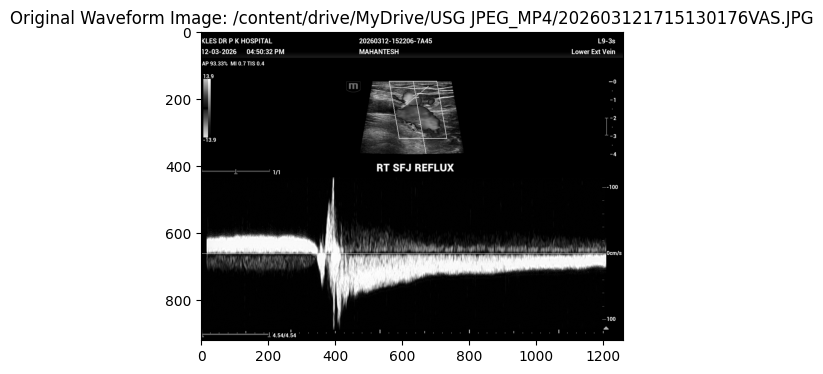

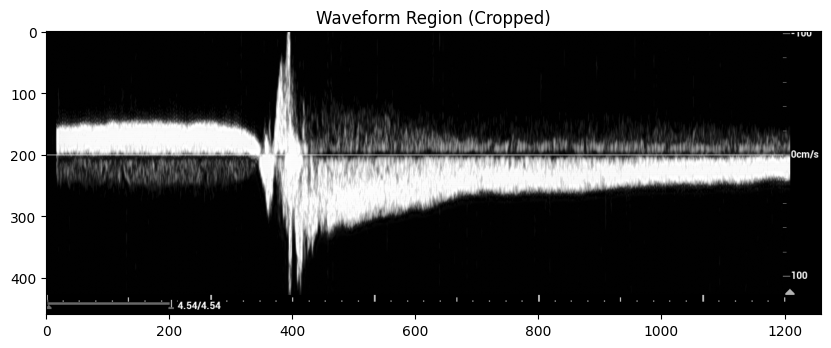

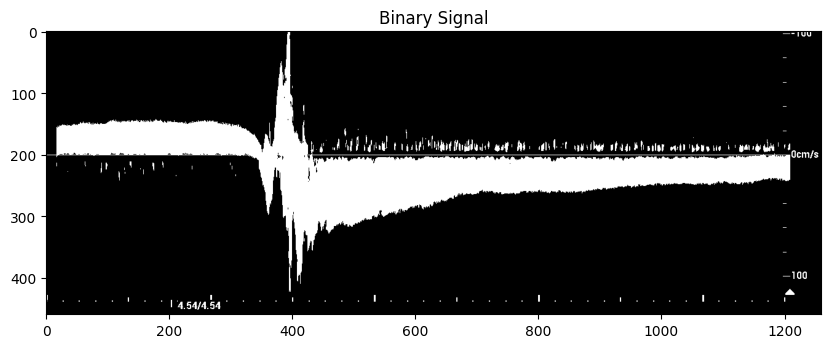

Detected baseline at row: 230
Extracted signal length: 1260
Reflux length (pixels): 836
Estimated reflux duration: 4.38 seconds
Clinical Interpretation: Reflux Present

--- Processing MP4: 202603121716130178VAS.mp4 ---


NameError: name 'extract_frame_from_mp4' is not defined

In [ ]:
# List of image numbers provided by the user
image_numbers = ['176', '178', '182']
usg_dir = '/content/drive/MyDrive/USG JPEG_MP4'
dicom_dir = '/content/drive/MyDrive/DICOM/' # Define dicom_dir here

# Available files (from kernel state, or re-list if needed)
if 'usg_files' not in locals() and 'usg_files' not in globals():
    usg_files = os.listdir(usg_dir)

processed_files_count = 0
for num in image_numbers:
    found_file = None
    for f_name in usg_files:
        # Match both JPG and MP4 files
        if num in f_name and (f_name.endswith('.JPG') or f_name.endswith('.mp4')):
            found_file = f_name
            break

    if found_file:
        file_path = os.path.join(usg_dir, found_file)
        if file_path.endswith('.JPG'):
            img_data = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            if img_data is not None:
                run_reflux_pipeline(img_data, file_path, dicom_dir=dicom_dir, total_time_seconds=6.6)
                processed_files_count += 1
            else:
                print(f"Error: Could not load image {file_path}")
        elif file_path.endswith('.mp4'):
            print(f"\n--- Processing MP4: {found_file} ---")
            frame_data = extract_frame_from_mp4(file_path, frame_number=0) # Extract the first frame
            if frame_data is not None:
                run_reflux_pipeline(frame_data, file_path, dicom_dir=dicom_dir, total_time_seconds=6.6)
                processed_files_count += 1
            else:
                print(f"Error: Could not extract frame from {file_path}")
        else:
            print(f"\n--- Skipping {found_file} ---")
            print(f"Note: {found_file} has an unsupported file extension.")
    else:
        print(f"\n--- Warning: File containing '{num}' not found in {usg_dir} ---")

if processed_files_count == 0:
    print("\nNo images or video frames were processed from the provided list.")
else:
    print(f"\nSuccessfully processed {processed_files_count} files (images and video frames).")